<a href="https://colab.research.google.com/github/NadiaKamel444/AI_DataScience.DataEngineer.DEPI4/blob/main/digital_leadership_de_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

          firm_id       grade  individualized_support  \
count  311.000000  311.000000              311.000000   
mean   156.000000    6.012862                2.969417   
std     89.922189    0.834631                1.154548   
min      1.000000    5.000000                1.020739   
25%     78.500000    5.000000                2.007701   
50%    156.000000    6.000000                2.926668   
75%    233.500000    7.000000                3.923374   
max    311.000000    7.000000                4.983725   

       inspirational_motivation         mea         mep  servant_leadership  \
count                311.000000  311.000000  311.000000          311.000000   
mean                   3.029427    3.090052    2.995066            2.965544   
std                    1.116874    1.154883    1.146943            1.089525   
min                    1.010380    1.000950    1.004118            1.001330   
25%                    2.049376    2.182095    1.945640            2.008451   
50%         

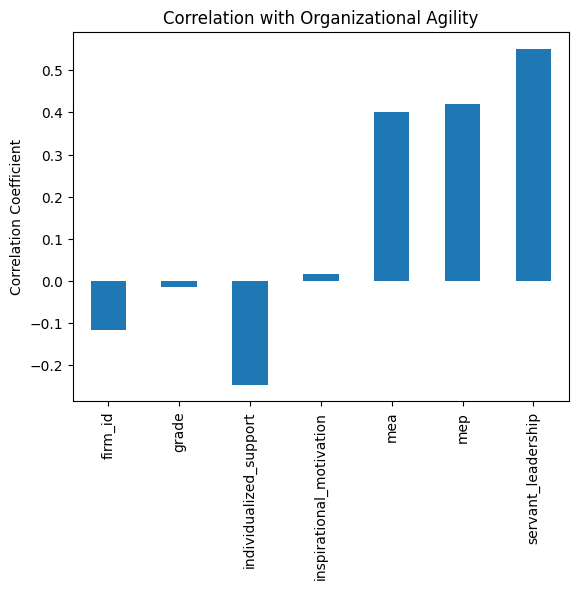

                              OLS Regression Results                              
Dep. Variable:     organizational_agility   R-squared:                       0.686
Model:                                OLS   Adj. R-squared:                  0.682
Method:                     Least Squares   F-statistic:                     167.3
Date:                    Tue, 03 Mar 2026   Prob (F-statistic):           1.04e-75
Time:                            07:50:23   Log-Likelihood:                -182.25
No. Observations:                     311   AIC:                             374.5
Df Residuals:                         306   BIC:                             393.2
Df Model:                               4                                         
Covariance Type:                nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

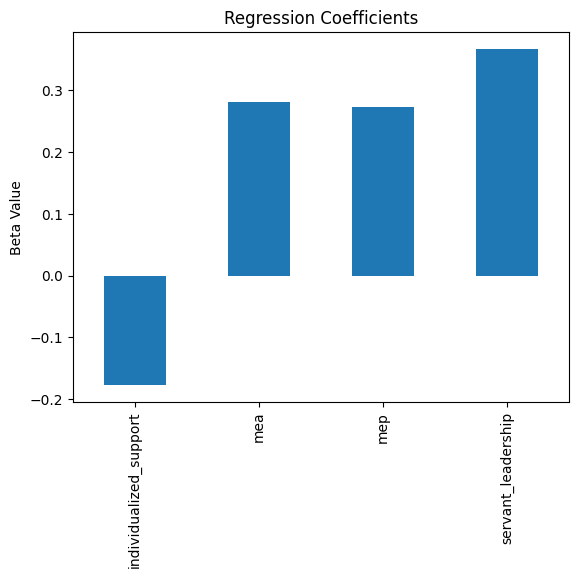

Linear Regression R2: 0.6235774173770057
Linear Regression MSE: 0.21139497693153828
Random Forest R2: 0.5364366459595635
Random Forest MSE: 0.2603323207944496


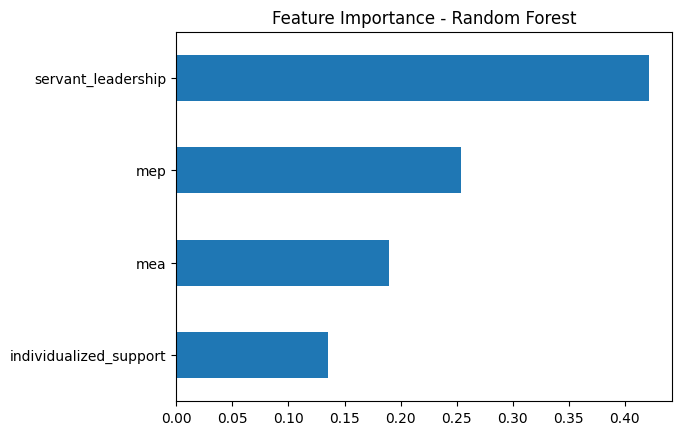

Gradient Boosting R2: 0.5171191116953634
Gradient Boosting MSE: 0.2711808455606822
               Model  R2 Score       MSE
0  Linear Regression  0.623577  0.211395
1      Random Forest  0.536437  0.260332
2  Gradient Boosting  0.517119  0.271181


['scaler.pkl']

In [ ]:
# 0️⃣ Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# For reproducibility
np.random.seed(42)

# 1️⃣ Generate Simulated Dataset
n = 311  # Number of construction firms

data = pd.DataFrame({
    "firm_id": range(1, n+1),
    "grade": np.random.choice([5,6,7], size=n),
    "individualized_support": np.random.uniform(1,5,n),
    "inspirational_motivation": np.random.uniform(1,5,n),
    "mea": np.random.uniform(1,5,n),
    "mep": np.random.uniform(1,5,n),
    "servant_leadership": np.random.uniform(1,5,n)
})

# Calculate Organizational Agility (OA)
data["organizational_agility"] = (
    -0.2 * data["individualized_support"] +
    0.3 * data["mea"] +
    0.25 * data["mep"] +
    0.4 * data["servant_leadership"] +
    np.random.normal(0, 0.5, n)
)
data["organizational_agility"] = np.clip(data["organizational_agility"], 1, 5)

# Save dataset for GitHub
data.to_csv("construction_leadership_dataset.csv", index=False)

# 2️⃣ Descriptive Statistics
print(data.describe())

# 3️⃣ Correlation Analysis
corr_matrix = data.corr()
corr_with_oa = corr_matrix["organizational_agility"].drop("organizational_agility")
print("Correlation with OA:\n", corr_with_oa)

# Plot Correlation
corr_with_oa.plot(kind="bar", title="Correlation with Organizational Agility")
plt.ylabel("Correlation Coefficient")
plt.show()

# 4️⃣ Regression Analysis (OLS)
X = data[["individualized_support", "mea", "mep", "servant_leadership"]]
X = sm.add_constant(X)
y = data["organizational_agility"]

model = sm.OLS(y, X).fit()
print(model.summary())

# 5️⃣ Visualize Regression Coefficients
coeffs = model.params.drop("const")
coeffs.plot(kind="bar", title="Regression Coefficients")
plt.ylabel("Beta Value")
plt.show()

# 6️⃣ Train-Test Split for ML
X_ml = data[["individualized_support", "mea", "mep", "servant_leadership"]]
y_ml = data["organizational_agility"]
X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)

# 7️⃣ Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 8️⃣ Linear Regression (Baseline)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
print("Linear Regression R2:", r2_score(y_test, lr_pred))
print("Linear Regression MSE:", mean_squared_error(y_test, lr_pred))

# 9️⃣ Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest R2:", r2_score(y_test, rf_pred))
print("Random Forest MSE:", mean_squared_error(y_test, rf_pred))

# Feature Importance - Random Forest
importance = pd.Series(rf.feature_importances_, index=X_ml.columns)
importance.sort_values().plot(kind="barh", title="Feature Importance - Random Forest")
plt.show()

# 10️⃣ Gradient Boosting
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
print("Gradient Boosting R2:", r2_score(y_test, gb_pred))
print("Gradient Boosting MSE:", mean_squared_error(y_test, gb_pred))

# 11️⃣ Model Comparison Table
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred)
    ],
    "MSE": [
        mean_squared_error(y_test, lr_pred),
        mean_squared_error(y_test, rf_pred),
        mean_squared_error(y_test, gb_pred)
    ]
})
print(results)

# 12️⃣ Save Best Model
joblib.dump(rf, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")